# NB04.1: SupraGraphNet | Esquemas de etiquetado clinico

Variante del notebook principal que explora tres esquemas de clasificacion basados en umbrales de la literatura HNSCC, en lugar de la mediana empirica usada en NB04. El objetivo es comprobar si los cortes clinicamente establecidos mejoran la señal de supervivencia o si la cohorte TCGA no tiene suficiente poder estadistico para discriminar entre mas de dos clases.

**Cambios respecto a NB04:**
- Tres esquemas de etiquetado en lugar de la mediana: 3 clases literatura, 4 clases literatura y 4 cuartiles empiricos
- Optuna sin hardcodeo — los mejores hiperparametros pasan directamente al K-Fold final
- Clasificacion multiclase con softmax y AUC OvR macro

**Entradas:** `hetero_graph_all.pt`, `hpv_encoded.csv`, `gnn_models_v2.py`

**Salidas:** `all_results` en memoria con metricas por esquema y fold

## PASO 0: Setup y carga

Montaje de Drive, dependencias y semillas de reproducibilidad.

In [ ]:
from google.colab import drive
import os, sys
drive.mount('/content/drive')
carpeta_proyecto = '/content/drive/MyDrive/TFM'
os.chdir(carpeta_proyecto)
sys.path.append(carpeta_proyecto)
print('Directorio:', os.getcwd())


Mounted at /content/drive
Directorio: /content/drive/MyDrive/TFM


In [ ]:
!pip install pyvis networkx statsmodels python-louvain optuna -q
!pip install -r requirements.txt -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.8 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import sys, gc, numpy as np, pandas as pd
import torch, torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from scipy import stats
import warnings, importlib, random
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [ ]:
PROCESSED_DIR = Path('data/processed_hnsc')
graph_all_pt  = PROCESSED_DIR / 'hetero_graph_all.pt'
hpv_file      = PROCESSED_DIR / 'hpv_encoded.csv'

# ── Módulo v2 (multiclase) ────────────────────────────────────────────
src_path = Path('src')
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hnsc_graph.gnn_models_v2 as gnn_module
importlib.reload(gnn_module)
from hnsc_graph.gnn_models_v2 import (
    SupraGraphNetConfig, SupraGraphNet,
    train_supra_graph_classifier,
    make_optuna_objective_classifier,
    compute_classification_metrics,
    get_attention_weights, get_attention_edge_importance,
    run_gnnexplainer,
)
print(' gnn_models_v2 cargado')


✅ gnn_models_v2 cargado


In [ ]:
graph_all = torch.load(graph_all_pt, weights_only=False)

for rel in [('mirna','coexpresses','mirna'), ('mirna','represses','isoform')]:
    if rel not in graph_all.edge_types: continue
    ei    = graph_all[rel].edge_index
    n_src = graph_all[rel[0]].x.shape[0]
    n_dst = graph_all[rel[2]].x.shape[0]
    mask  = (ei[0] < n_src) & (ei[1] < n_dst)
    graph_all[rel].edge_index = ei[:, mask]
    if hasattr(graph_all[rel], 'edge_attr'):
        graph_all[rel].edge_attr = graph_all[rel].edge_attr[mask]

barcodes_all = list(graph_all.barcodes)
n_patients   = len(barcodes_all)
n_mirna      = graph_all['mirna'].x.shape[0]
n_isoform    = graph_all['isoform'].x.shape[0]

os_time_np   = graph_all.os_time.float().numpy()
os_event_np  = graph_all.os_event.float().numpy()
dead_mask    = (os_event_np == 1)
dead_indices = np.where(dead_mask)[0]

print(f'Grafo: {n_mirna} miRNAs | {n_isoform} isoformas | {n_patients} pacientes')
print(f'Fallecidos (OS=1): {len(dead_indices)}')

hpv_df     = pd.read_csv(hpv_file, index_col=0)
hpv_values = np.array([
    hpv_df.loc[b, 'hpv_positive'] if b in hpv_df.index else 0
    for b in barcodes_all
], dtype=np.float32)
hpv_tensor = torch.tensor(hpv_values, dtype=torch.float32)
print(f'HPV+ fallecidos: {int((hpv_values[dead_mask]==1).sum())}')

base_config_kwargs = dict(num_mirna=n_mirna, num_mrna=n_isoform, num_patients=n_patients)


Grafo: 590 miRNAs | 5305 isoformas | 474 pacientes
Fallecidos (OS=1): 198
HPV+ fallecidos: 24


## PASO 1: Etiquetas: tres esquemas de clasificacion

Se generan tres conjuntos de etiquetas sobre los mismos fallecidos (OS=1). Los censurados reciben NaN y no participan en train ni validacion.

| Esquema | Clases | Cortes | Criterio |
|---|---|---|---|
| `3class` | 3 | <1a / 1-5a / >5a | Umbrales clinicos HNSCC literatura |
| `4class` | 4 | <1a / 1-3a / 3-5a / >5a | Umbrales clinicos — desbalanceado (n=14 en 3-5a) |
| `4quartile` | 4 | Q1 / Q2 / Q3 / Q4 del OS.time | Balanceado (~50 por clase), cortes empiricos de la cohorte |

Los dos graficos siguientes verifican que los cortes producen grupos coherentes: distribucion de n por clase y boxplot de OS.time por clase.

In [ ]:
# ── Umbrales literatura (días) ────────────────────────────────────────
THR_1Y = 365
THR_3Y = 365 * 3
THR_5Y = 365 * 5

# ── Cuartiles empíricos sobre OS.time de fallecidos ───────────────────
os_dead   = os_time_np[dead_mask]
Q1, Q2, Q3 = np.percentile(os_dead, [25, 50, 75])
print(f'Cuartiles OS.time fallecidos:')
print(f'  Q1={Q1:.0f}d ({Q1/365:.1f}a)  Q2={Q2:.0f}d ({Q2/365:.1f}a)  Q3={Q3:.0f}d ({Q3/365:.1f}a)')

def make_labels(os_time_np, os_event_np, scheme):
    """
    Genera tensor de labels para fallecidos. Censurados → NaN.

    scheme='3class'   : 0=Corta(<1a), 1=Media(1-5a), 2=Larga(>5a)
    scheme='4class'   : 0=<1a, 1=1-3a, 2=3-5a, 3=>5a
    scheme='4quartile': 0=Q1, 1=Q2, 2=Q3, 3=Q4  (cuartiles OS.time fallecidos)
    """
    labels = torch.full((len(os_time_np),), float('nan'))
    for i in range(len(os_time_np)):
        if os_event_np[i] != 1:
            continue
        t = os_time_np[i]
        if scheme == '3class':
            labels[i] = 0.0 if t < THR_1Y else (1.0 if t <= THR_5Y else 2.0)
        elif scheme == '4class':
            if   t <  THR_1Y: labels[i] = 0.0
            elif t <= THR_3Y: labels[i] = 1.0
            elif t <= THR_5Y: labels[i] = 2.0
            else:             labels[i] = 3.0
        elif scheme == '4quartile':
            if   t <= Q1: labels[i] = 0.0
            elif t <= Q2: labels[i] = 1.0
            elif t <= Q3: labels[i] = 2.0
            else:         labels[i] = 3.0
    return labels

labels_3q  = make_labels(os_time_np, os_event_np, '3class')
labels_4lit = make_labels(os_time_np, os_event_np, '4class')
labels_4qu  = make_labels(os_time_np, os_event_np, '4quartile')

# Índices de fallecidos con label válida (igual para los 3 esquemas)
idx_valid = np.where(~torch.isnan(labels_3q).numpy())[0]

# Resumen
SCHEMES = [
    ('3class',    labels_3q,   3, ['Corta (<1a)',    'Media (1–5a)',     'Larga (>5a)']),
    ('4class',    labels_4lit, 4, ['<1a',            '1–3a',             '3–5a',            '>5a']),
    ('4quartile', labels_4qu,  4, ['Q1 (más corta)', 'Q2',               'Q3',              'Q4 (más larga)']),
]

for scheme, labels, nc, nombres in SCHEMES:
    vals = labels[idx_valid].numpy().astype(int)
    print(f'\n── {scheme} ──────────────────────────────────────────')
    for c, nom in enumerate(nombres):
        n_c = (vals == c).sum()
        print(f'  Clase {c} [{nom}]: n={n_c}  ({n_c/len(vals)*100:.1f}%)')


Cuartiles OS.time fallecidos:
  Q1=260d (0.7a)  Q2=450d (1.2a)  Q3=819d (2.2a)

── 3class ──────────────────────────────────────────
  Clase 0 [Corta (<1a)]: n=76  (38.4%)
  Clase 1 [Media (1–5a)]: n=103  (52.0%)
  Clase 2 [Larga (>5a)]: n=19  (9.6%)

── 4class ──────────────────────────────────────────
  Clase 0 [<1a]: n=76  (38.4%)
  Clase 1 [1–3a]: n=89  (44.9%)
  Clase 2 [3–5a]: n=14  (7.1%)
  Clase 3 [>5a]: n=19  (9.6%)

── 4quartile ──────────────────────────────────────────
  Clase 0 [Q1 (más corta)]: n=50  (25.3%)
  Clase 1 [Q2]: n=49  (24.7%)
  Clase 2 [Q3]: n=49  (24.7%)
  Clase 3 [Q4 (más larga)]: n=50  (25.3%)


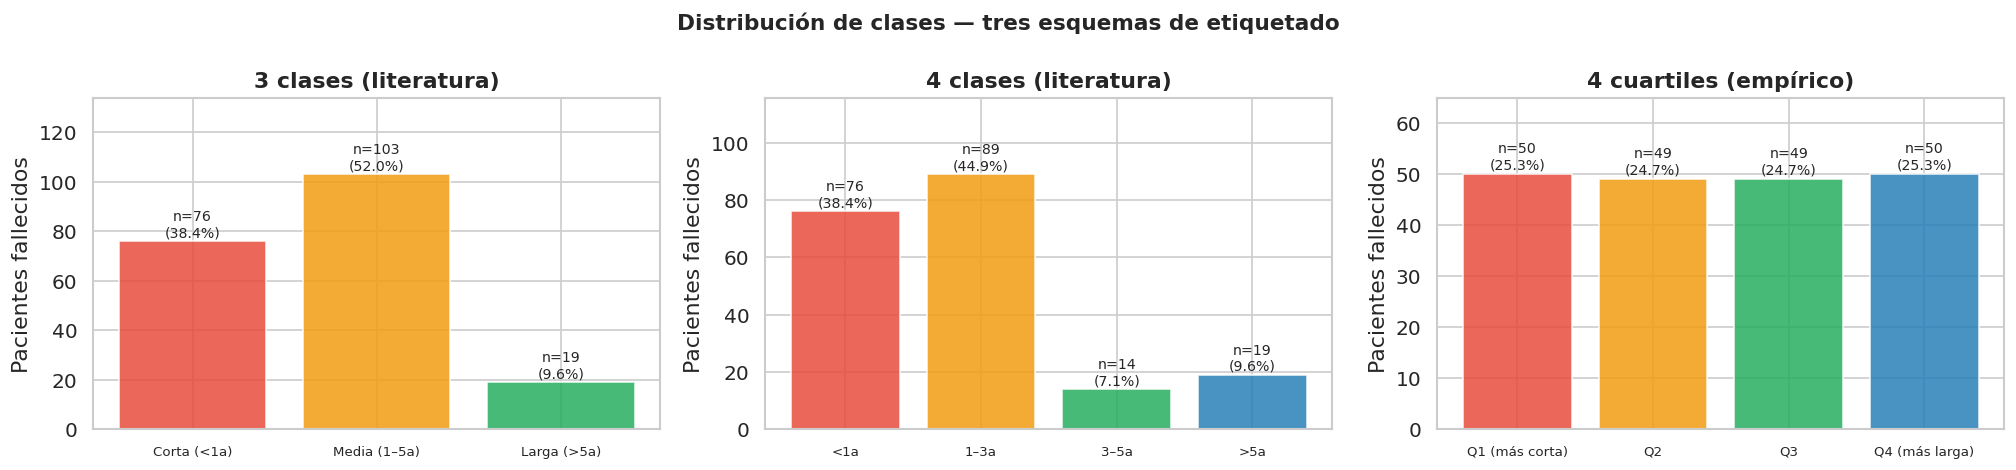

In [ ]:
# ── Visualización distribución de clases ─────────────────────────────
colores = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

titulos = ['3 clases (literatura)', '4 clases (literatura)', '4 cuartiles (empírico)']
for ax, (scheme, labels, nc, nombres), titulo in zip(axes, SCHEMES, titulos):
    vals  = labels[idx_valid].numpy().astype(int)
    cnts  = [(vals == c).sum() for c in range(nc)]
    total = len(vals)
    bars  = ax.bar(nombres, cnts, color=colores[:nc], alpha=0.85, edgecolor='white')
    for bar, n_c in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'n={n_c}\n({n_c/total*100:.1f}%)', ha='center', va='bottom', fontsize=8.5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Pacientes fallecidos')
    ax.set_ylim(0, max(cnts) * 1.3)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Distribución de clases — tres esquemas de etiquetado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


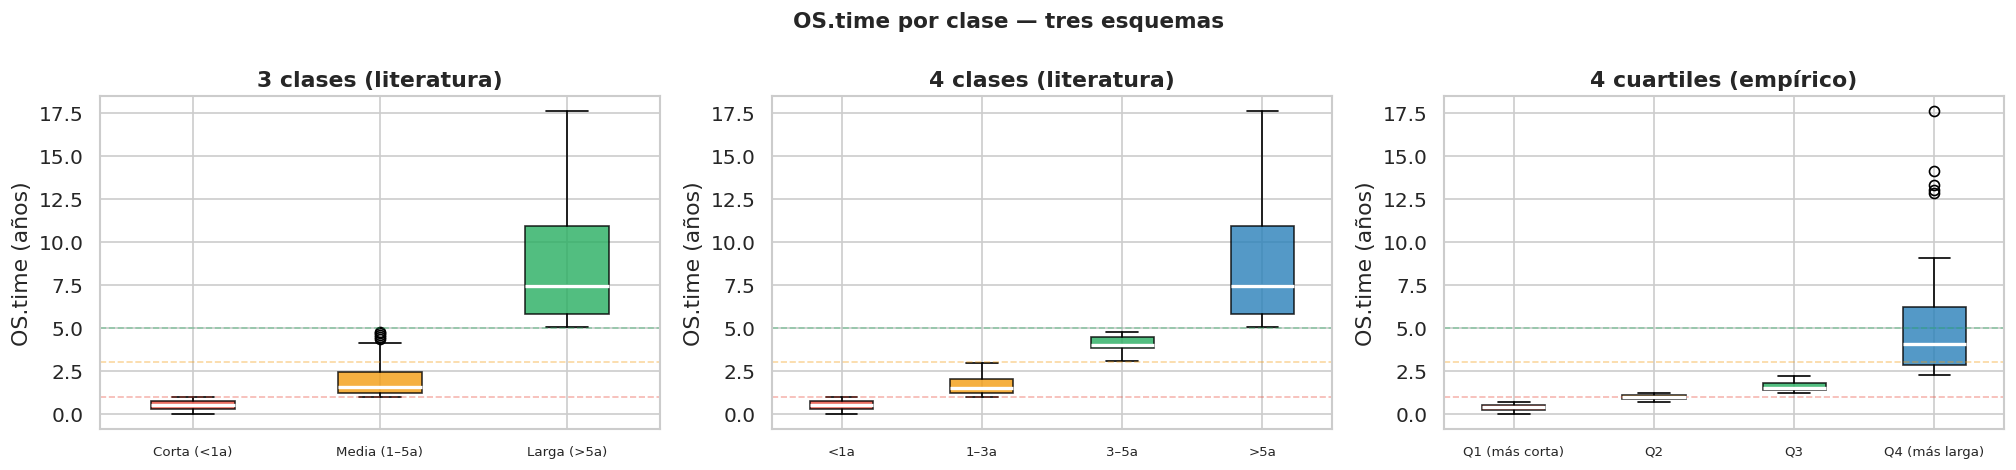

In [ ]:
# ── OS.time por clase (boxplot) ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, (scheme, labels, nc, nombres), titulo in zip(axes, SCHEMES, titulos):
    vals   = labels[idx_valid].numpy().astype(int)
    grupos = [os_time_np[idx_valid][vals == c] / 365 for c in range(nc)]
    bp = ax.boxplot(grupos, labels=nombres, patch_artist=True, widths=0.45,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colores[:nc]):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_ylabel('OS.time (años)')
    ax.set_title(titulo, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    # Líneas de referencia literatura
    for thr_y, col_l in [(1,'#e74c3c'),(3,'#f39c12'),(5,'#27ae60')]:
        ax.axhline(thr_y, color=col_l, linestyle='--', lw=1, alpha=0.4)

plt.suptitle('OS.time por clase — tres esquemas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## PASO 2: Optuna: busqueda de hiperparametros

Un estudio Optuna independiente por esquema de etiquetado. 25 trials x 500 epochs x 4 folds con MedianPruner. Los mejores parametros se pasan directamente al K-Fold final.

In [ ]:
import optuna
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS       = 25
EPOCHS_TRIAL   = 500
EARLY_TRIAL    = 150
N_FOLDS_OPTUNA = 4

studies = {}

for scheme, labels, nc, nombres in SCHEMES:
    print(f'\n🔍 Optuna [{scheme}] ({nc} clases) — {N_TRIALS} trials × {EPOCHS_TRIAL} epochs × {N_FOLDS_OPTUNA} folds...')

    objective = make_optuna_objective_classifier(
        data                      = graph_all,
        labels                    = labels,
        q14_indices               = idx_valid,
        base_config_kwargs        = base_config_kwargs,
        hpv                       = hpv_tensor,
        num_epochs_trial          = EPOCHS_TRIAL,
        early_stop_patience_trial = EARLY_TRIAL,
        n_folds                   = N_FOLDS_OPTUNA,
        seed                      = SEED,
        num_classes               = nc,
    )
    study = optuna.create_study(
        direction  = 'minimize',
        pruner     = MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name = f'supragraphnet_v8_{scheme}',
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    studies[scheme] = study

    print(f'  ✅ [{scheme}] Mejor AUC_val (media {N_FOLDS_OPTUNA} folds): {1 - study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'    {k}: {v}')



🔍 Optuna [3class] (3 clases) — 25 trials × 500 epochs × 4 folds...


  0%|          | 0/25 [00:00<?, ?it/s]

  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  155/500  loss 0.2095  AUC 0.473
  ⏹️  Early stopping en época 155  |  mejor AUC: 0.5872
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.2230  AUC 0.398
  ⏹️  Early stopping en época 150  |  mejor AUC: 0.4995
  [██████████░░░░░░░░░░░░░░░░░░░░] ep  170/500  loss 0.2126  AUC 0.442
  ⏹️  Early stopping en época 170  |  mejor AUC: 0.5011
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.2116  AUC 0.468
  ⏹️  Early stopping en época 150  |  mejor AUC: 0.6338
  [████████████░░░░░░░░░░░░░░░░░░] ep  205/500  loss 0.1811  AUC 0.382
  ⏹️  Early stopping en época 205  |  mejor AUC: 0.5568
  [████████████████████████████░░] ep  475/500  loss 0.1709  AUC 0.451
  ⏹️  Early stopping en época 475  |  mejor AUC: 0.4567
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  155/500  loss 0.1841  AUC 0.529
  ⏹️  Early stopping en época 155  |  mejor AUC: 0.5775
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.1665  AUC 0.338
  ⏹️  Early stopping en época 150  |  me

  0%|          | 0/25 [00:00<?, ?it/s]

  [██████████████░░░░░░░░░░░░░░░░] ep  240/500  loss 0.3403  AUC 0.463
  ⏹️  Early stopping en época 240  |  mejor AUC: 0.5151
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.3579  AUC 0.427
  ⏹️  Early stopping en época 150  |  mejor AUC: 0.5854
  [██████████████░░░░░░░░░░░░░░░░] ep  245/500  loss 0.3246  AUC 0.482
  ⏹️  Early stopping en época 245  |  mejor AUC: 0.5344
  [████████████░░░░░░░░░░░░░░░░░░] ep  205/500  loss 0.3830  AUC 0.577
  ⏹️  Early stopping en época 205  |  mejor AUC: 0.6280
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.3984  AUC 0.335
  ⏹️  Early stopping en época 150  |  mejor AUC: 0.5311
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.4032  AUC 0.454
  ⏹️  Early stopping en época 150  |  mejor AUC: 0.5875
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  165/500  loss 0.3959  AUC 0.513
  ⏹️  Early stopping en época 165  |  mejor AUC: 0.5268
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  155/500  loss 0.4191  AUC 0.594
  ⏹️  Early stopping en época 155  |  me

  0%|          | 0/25 [00:00<?, ?it/s]

  [███████████████░░░░░░░░░░░░░░░] ep  250/500  loss 0.9656  AUC 0.442
  ⏹️  Early stopping en época 250  |  mejor AUC: 0.4994
  [████████████░░░░░░░░░░░░░░░░░░] ep  205/500  loss 0.9538  AUC 0.488
  ⏹️  Early stopping en época 205  |  mejor AUC: 0.5616
  [████████████████████░░░░░░░░░░] ep  345/500  loss 0.9654  AUC 0.544
  ⏹️  Early stopping en época 345  |  mejor AUC: 0.5957
  [█████████████░░░░░░░░░░░░░░░░░] ep  220/500  loss 0.9639  AUC 0.553
  ⏹️  Early stopping en época 220  |  mejor AUC: 0.5576
  [███████████████░░░░░░░░░░░░░░░] ep  255/500  loss 0.7819  AUC 0.417
  ⏹️  Early stopping en época 255  |  mejor AUC: 0.4992
  [████████████░░░░░░░░░░░░░░░░░░] ep  210/500  loss 0.7466  AUC 0.490
  ⏹️  Early stopping en época 210  |  mejor AUC: 0.5727
  [█████████████████████░░░░░░░░░] ep  360/500  loss 0.7745  AUC 0.501
  ⏹️  Early stopping en época 360  |  mejor AUC: 0.5993
  [█████████████████████░░░░░░░░░] ep  360/500  loss 0.7938  AUC 0.539
  ⏹️  Early stopping en época 360  |  me

## PASO 3: Entrenamiento K-Fold y metricas

4-Fold estratificado por clase para cada esquema, con los hiperparametros de Optuna. Hasta 1000 epochs con early stopping a 400.

 El resumen comparativo al final incluye la referencia binaria de NB04 para contextualizar si la granularidad adicional aporta o perjudica la discriminacion.

In [ ]:
N_FOLDS       = 4
NUM_EPOCHS    = 1000
EARLY_STOP    = 400
MAX_RETRIES   = 3
AUC_RETRY_THR = 0.55

all_results = {}

for scheme, labels, nc, nombres in SCHEMES:
    best_params = studies[scheme].best_params
    print(f'\n{"="*60}')
    print(f'  K-FOLD [{scheme}]  — {nc} clases | {len(idx_valid)} fallecidos')
    print(f'  Optuna: hd={best_params["hidden_dim"]} heads={best_params["heads"]} '
          f'lr={best_params["lr"]:.1e} γ={best_params["focal_gamma"]:.2f}')
    print(f'={"="*59}')

    best_config = SupraGraphNetConfig(
        **base_config_kwargs,
        hidden_dim     = best_params['hidden_dim'],
        heads          = best_params['heads'],
        os_head_dim    = 16,
        dropout        = best_params['dropout'],
        expr_embed_dim = best_params['expr_embed_dim'],
        hpv_embed_dim  = best_params['hpv_embed_dim'],
        num_classes    = nc,
    )

    labels_idx = labels[idx_valid].numpy().astype(int)
    skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_metrics    = []
    fold_models     = []
    fold_train_hist = []
    fold_val_hist   = []
    best_auc_global = 0.0
    best_model      = None
    best_fold_idx   = -1
    best_state      = None

    for fold, (train_rel, val_rel) in enumerate(skf.split(idx_valid, labels_idx), start=1):
        train_idx_fold = idx_valid[train_rel]
        val_idx_fold   = idx_valid[val_rel]

        print(f'\n  FOLD {fold}/{N_FOLDS} | train={len(train_idx_fold)} val={len(val_idx_fold)}')
        for c, nom in enumerate(nombres):
            n_c = (labels[train_idx_fold].numpy() == c).sum()
            print(f'    [{nom}]: {n_c} train', end='  ')
        print()

        best_fold_auc = 0.0; best_fold_model = None; best_fold_metrics = None

        for retry in range(MAX_RETRIES):
            torch.manual_seed(SEED + fold * 10 + retry)
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

            model_fold, metrics_fold = train_supra_graph_classifier(
                data                = graph_all,
                labels              = labels,
                train_idx           = train_idx_fold,
                val_idx             = val_idx_fold,
                config              = best_config,
                hpv                 = hpv_tensor,
                num_epochs          = NUM_EPOCHS,
                lr                  = best_params['lr'],
                weight_decay        = best_params['weight_decay'],
                early_stop_patience = EARLY_STOP,
                noise_std           = best_params['noise_std'],
                focal_gamma         = best_params['focal_gamma'],
                label_smoothing     = best_params['label_smoothing'],
            )

            auc_v = metrics_fold['val_auc']
            print(f'    → Intento {retry+1}: AUC={auc_v:.4f}')

            if auc_v > best_fold_auc:
                best_fold_auc = auc_v; best_fold_model = model_fold; best_fold_metrics = metrics_fold
            if auc_v >= AUC_RETRY_THR:
                break

        fold_metrics.append(best_fold_metrics)
        fold_models.append(best_fold_model)
        fold_train_hist.append(best_fold_metrics['train_history'])
        fold_val_hist.append(best_fold_metrics['val_history'])

        if best_fold_auc > best_auc_global:
            best_auc_global = best_fold_auc; best_model = best_fold_model
            best_fold_idx   = fold
            best_state      = {k: v.cpu().clone() for k, v in best_fold_model.state_dict().items()}

        print(f'   Fold {fold} — AUC={best_fold_auc:.4f}')

    all_results[scheme] = {
        'fold_metrics'   : fold_metrics,
        'fold_models'    : fold_models,
        'fold_train_hist': fold_train_hist,
        'fold_val_hist'  : fold_val_hist,
        'best_auc_global': best_auc_global,
        'best_model'     : best_model,
        'best_fold_idx'  : best_fold_idx,
        'best_state'     : best_state,
        'best_config'    : best_config,
        'best_params'    : best_params,
        'labels'         : labels,
        'num_classes'    : nc,
        'nombres'        : nombres,
    }
    print(f'\n   [{scheme}] Mejor fold: {best_fold_idx} — AUC={best_auc_global:.4f}')



  K-FOLD [3class]  — 3 clases | 198 fallecidos
  Optuna: hd=96 heads=4 lr=4.5e-04 γ=3.26

  FOLD 1/4 | train=148 val=50
    [Corta (<1a)]: 57 train      [Media (1–5a)]: 77 train      [Larga (>5a)]: 14 train  
  [█████████████████████░░░░░░░░░] ep  705/1000  loss 0.2013  AUC 0.573
  ⏹️  Early stopping en época 705  |  mejor AUC: 0.6424
    → Intento 1: AUC=0.6424
  ✅ Fold 1 — AUC=0.6424

  FOLD 2/4 | train=148 val=50
    [Corta (<1a)]: 57 train      [Media (1–5a)]: 77 train      [Larga (>5a)]: 14 train  
  [████████████░░░░░░░░░░░░░░░░░░] ep  400/1000  loss 0.2075  AUC 0.491
  ⏹️  Early stopping en época 400  |  mejor AUC: 0.5083
    → Intento 1: AUC=0.5083
  [████████████████████████░░░░░░] ep  810/1000  loss 0.2033  AUC 0.472
  ⏹️  Early stopping en época 810  |  mejor AUC: 0.4962
    → Intento 2: AUC=0.4962
  [███████████████████░░░░░░░░░░░] ep  640/1000  loss 0.1998  AUC 0.471
  ⏹️  Early stopping en época 640  |  mejor AUC: 0.5092
    → Intento 3: AUC=0.5092
  ✅ Fold 2 — AUC=0.509

In [ ]:
# ── Resumen comparativo ───────────────────────────────────────────────
# Referencia: SupraGraphNet clasificación binaria mediana (NB04)
REF_NOMBRE = 'binario mediana (NB04)'
REF_AUC    = 0.6480
REF_STD    = 0.0430
REF_BEST   = 0.7140

print('\n' + '='*65)
print('  RESUMEN COMPARATIVO  esquemas de etiquetado')
print('='*65)
print(f'  {"Esquema":<30} {"AUC media":>10}  {"± std":>7}  {"Mejor fold":>10}')
print(f'  {"-"*55}')
print(f'  {REF_NOMBRE:<30} {REF_AUC:>10.4f}  {REF_STD:>7.4f}  {REF_BEST:>10.4f}')
print(f'  {"-"*55}')

for scheme, _, nc, _ in SCHEMES:
    r    = all_results[scheme]
    fms  = r['fold_metrics']
    aucs = [m['val_auc'] for m in fms]
    print(f'  {scheme:<30} {np.mean(aucs):>10.4f}  {np.std(aucs):>7.4f}  {r["best_auc_global"]:>10.4f}')



  RESUMEN COMPARATIVO — esquemas de etiquetado
  Esquema                         AUC media    ± std  Mejor fold
  -------------------------------------------------------
  binario mediana (NB04)             0.6480   0.0430      0.7140
  -------------------------------------------------------
  3class                             0.5759   0.0471      0.6424
  4class                             0.5768   0.0261      0.6082
  4quartile                          0.5822   0.0270      0.6287


## Conclusion

El esquema binario por mediana (NB04) supera a los tres esquemas multiclase en todas las metricas.
El mejor fold alcanza AUC=0.714 frente a 0.642 del mejor esquema de 3 clases.

Esto no es sorprendente dado el tamaño de la cohorte: con 220 fallecidos y 4 folds, cada fold de
validacion tiene ~55 pacientes. Dividirlos en 3 o 4 clases deja grupos de 10-15 pacientes por clase,
insuficiente para que el modelo aprenda fronteras de decision estables. La penalizacion es mayor en
`4class` porque el grupo 3-5a tiene solo n=14 en toda la cohorte.

El esquema `4quartile` es el menos malo de los multiclase porque los cortes empiricos garantizan
grupos balanceados (~50 por clase), pero aun asi pierde 7 puntos de AUC media respecto al binario.

**Decision:** se mantiene el esquema binario por mediana de NB04 como formulacion definitiva del
problema. Los esquemas multiclase quedan documentados aqui como evidencia de que la granularidad
adicional no esta justificada con esta cohorte.

## Continua en seccion 4

Analisis de atencion, GNNExplainer y guardado de resultados.